In [3]:
import networkx as nx
import matplotlib.pyplot as plt


In [4]:
def unitary_cayley(f, R):
    """
    This function return the unitary Cayley graph on F_q[x]/f
    """
    
    n = f.degree()-1
    vertice = elements_quotient_ring = list(R.polynomials(max_degree=n))
    n = len(vertice)
    g=nx.empty_graph(n)
    for i in range(0,n):
        for j in range(0,n):
            if gcd(vertice[i]-vertice[j],f) ==1:
                g.add_edge(i,j)
    return g  

def gcd_cayley(f, R, D):
    """
    return the gcd graph G_f(D)
    """
    n = f.degree()-1
    vertice = elements_quotient_ring = list(R.polynomials(max_degree=n))
    n = len(vertice)
    g=nx.empty_graph(n)
    for i in range(0,n):
        for j in range(0,n):
            if (gcd(vertice[i]-vertice[j],f) in D) or (gcd(vertice[j]-vertice[i],f) in D):
                g.add_edge(i,j)
    return g 

def abstract_gcd_cayley(f, R, D):
    n = f.degree()-1
    vertice = elements_quotient_ring = list(R.polynomials(max_degree=n))
    n = len(vertice)
    g=nx.empty_graph(vertice)
    for i in vertice:
        for j in vertice:
            if gcd(i-j,f) in D:
                g.add_edge(i,j)
    return g 

def induced_graph(g,v):
    n = len(v)
    induced_g=nx.empty_graph(n)
    for i in range(n):
        for j in range(n):
            if v[j] in g.neighbors(v[i]):
                induced_g.add_edge(i,j)
    return induced_g 

def new_gcd(f,g):
    if f % g ==0:
        return 0
    else:
        return gcd(f,g)
def char_poly_gcd_graph(g):
    adj_matrix = nx.adjacency_matrix(g).todense()
    matrix_size = g.number_of_nodes()
    matrix = adj_matrix
    f = MatrixSpace(IntegerRing(),matrix_size)(matrix).charpoly()
    return f.factor()
   

# Some examples



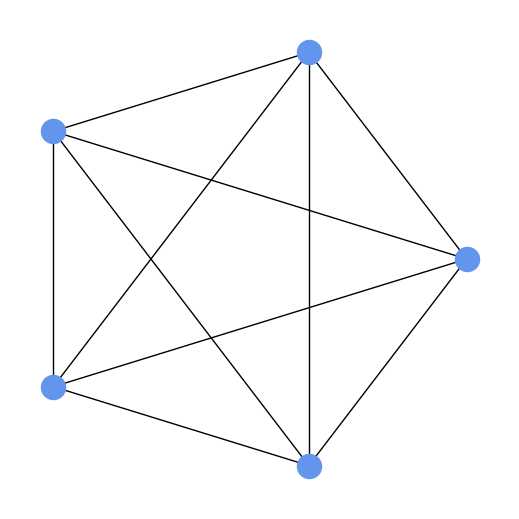

In [3]:
# The unitary Cayley graph on F_5[x]/x
F.<a> = GF(5)
R.<x> = PolynomialRing(F)
f = x
g = unitary_cayley(f,R)
fig = plt.gcf()
fig.set_size_inches(5,5)
pos = nx.circular_layout(g)
nx.draw(g, pos=pos,
       with_labels = False,
       #node_size = 600,
       #scale = 1,
       node_color = '#6495ED')

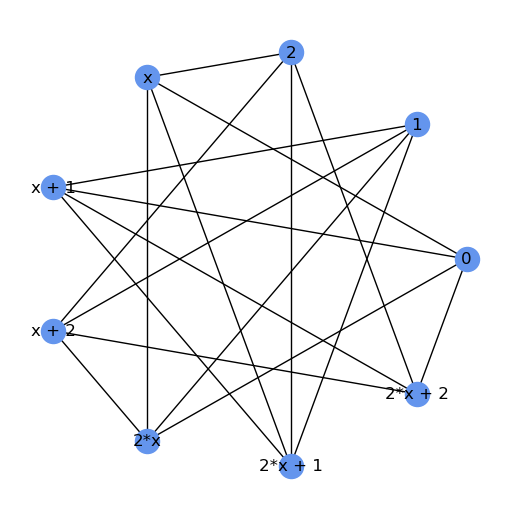

In [6]:
#The gcd graph G_f(D) over F_3[x] with f = x*(x+1) and D = {x, x+1}
F.<a> = GF(3)
R.<x> = PolynomialRing(F)
f = x*(x+1)
D = {x, x+1}
g = abstract_gcd_cayley(f,R, D)
fig = plt.gcf()
fig.set_size_inches(5,5)
pos = nx.circular_layout(g)
nx.draw(g, pos=pos,
       with_labels = True,
       #node_size = 600,
       #scale = 1,
       node_color = '#6495ED')
#plt.savefig("first_example.pdf", dpi = 300)

In [9]:
F= char_poly_gcd_graph(g)
F

(x - 4) * (x - 1)^4 * (x + 2)^4

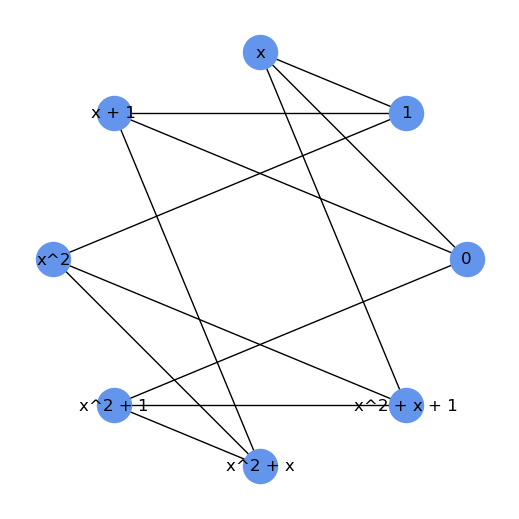

In [10]:
#The gcd graph G_f(D) over F_3[x] with f = x*(x+1) and D = {x, x+1}
F.<a> = GF(2)
R.<x> = PolynomialRing(F)
f = x**2 *(x+1)
D = {x, x+1}
g = abstract_gcd_cayley(f,R, D)
fig = plt.gcf()
fig.set_size_inches(5,5)
pos = nx.circular_layout(g)
nx.draw(g, pos=pos,
       with_labels = True,
       node_size = 600,
       #scale = 0.5,
       node_color = '#6495ED')
plt.savefig("second_example.pdf", dpi = 300)

In [11]:
F= char_poly_gcd_graph(g)
F

(x - 3) * (x + 3) * (x - 1)^3 * (x + 1)^3